## Cleanlab Audit & SMOTE

### 1. Setup & Load Data


In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

import cleanlab
from cleanlab.classification import CleanLearning

from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek

from sklearn.metrics import recall_score, precision_score, f1_score

import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Connect to DuckDB
conn = duckdb.connect("D:\\p1-fraud-detection\\data\\fraud.db")

# Build the SELECT query with the specific columns you identified
selected_columns = [
    "isFraud",
    "TransactionAmt",
    "TransactionDT",
    "ProductCD",
    "card1", "card2", "card3", "card4", "card5", "card6",
    "addr1", "addr2",
    "P_emaildomain", "R_emaildomain",
] + [f"C{i}" for i in range(1, 15)] + [f"D{i}" for i in range(1, 16)] + [f"V{i}" for i in range(1, 51)]

# Construct the SQL query
query = f"SELECT {', '.join(selected_columns)} FROM joined_transactions"

# Load only these columns
df = conn.execute(query).fetchdf()
conn.close()

print(f"Loaded {df.shape[0]} rows and {df.shape[1]} columns (target: ~93)")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**3:.2f} GB")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Loaded 590540 rows and 93 columns (target: ~93)


Memory usage: 0.54 GB


### 2. Feature Engineering: Time Features

Convert TransactionDT (seconds) to hour_of_day and day_of_week.

In [2]:
# Hour of day (0-23)
df['hour_of_day'] = (df['TransactionDT'] % 86400) // 3600

# Day of week (0=Monday relative, 6=Sunday)
df['day_of_week'] = (df['TransactionDT'] // 86400) % 7

# Drop the raw TransactionDT (we now have engineered features)
df = df.drop(columns=['TransactionDT'])

print(f"Shape after time engineering: {df.shape}")
print(df[['hour_of_day', 'day_of_week']].head())

Shape after time engineering: (590540, 94)
   hour_of_day  day_of_week
0           17            4
1           18            4
2           18            4
3           18            4
4           18            4


### 3. Convert Categorical Columns to Category dtype
 (Required for XGBoost `enable_categorical=True`)

In [3]:
# Separate features and target
X = df.drop(columns=['isFraud'])
y = df['isFraud'].astype(int)

# Identify object columns
object_cols = X.select_dtypes(include=['object']).columns.tolist()
print(f"Converting {len(object_cols)} columns to category: {object_cols}")

for col in object_cols:
    X[col] = X[col].astype('category')

print("Data types after conversion:")
print(X.dtypes.value_counts())

Converting 5 columns to category: ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain']


Data types after conversion:
float64     85
int64        3
category     1
category     1
category     1
category     1
category     1
Name: count, dtype: int64


### 4. Feature/Target Split & Train/Validation/Test Split
We split before Cleanlab and SMOTE so validation supports model selection while the test set remains untouched for final evaluation.

In [4]:
X_train_pool, X_test, y_train_pool, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Keep validation in the original class distribution; only the remaining training data reaches SMOTE
X_train, X_val, y_train, y_val = train_test_split(
    X_train_pool, y_train_pool, test_size=0.125, stratify=y_train_pool, random_state=42
)

print(f"Train shape: {X_train.shape}, Fraud %: {y_train.mean():.4f}")
print(f"Validation shape: {X_val.shape}, Fraud %: {y_val.mean():.4f}")
print(f"Test shape: {X_test.shape}, Fraud %: {y_test.mean():.4f}")

Train shape: (413378, 93), Fraud %: 0.0350
Validation shape: (59054, 93), Fraud %: 0.0350
Test shape: (118108, 93), Fraud %: 0.0350


### 4. Cleanlab Audit (on Training Set Only)
 We use a shallow XGBoost (`n_estimators=50, max_depth=4`) for speed vs. accuracy tradeoff.

In [5]:
# Shallow XGBoost with categorical support enabled
clf = XGBClassifier(
    n_estimators=50,
    max_depth=4,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    enable_categorical=True
)

cleaner = CleanLearning(clf, seed=42)
label_issues = cleaner.find_label_issues(X_train, y_train)

print(f"Total samples in train set: {len(y_train)}")
print(f"Number of potential label issues flagged: {label_issues['is_label_issue'].sum()}")
print(f"Percentage of train set flagged: {label_issues['is_label_issue'].mean()*100:.2f}%")


Total samples in train set: 413378
Number of potential label issues flagged: 4620
Percentage of train set flagged: 1.12%


 ### 6. Analyze Flagged Fraud Samples
**Question:** Are the flagged fraud samples different in TransactionAmt?

Total fraud in train: 14464
Fraud samples flagged as likely mislabeled: 3830
Percentage of fraud class flagged: 26.48%


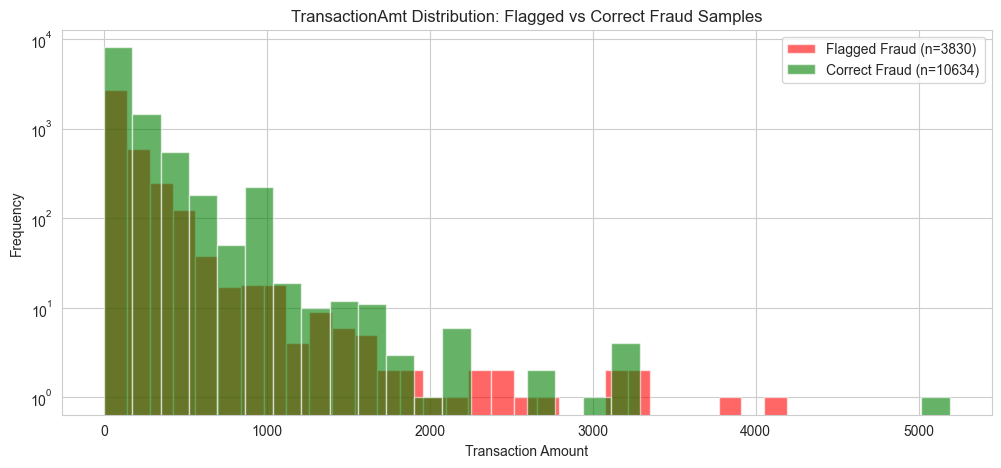

In [6]:
flagged_indices = label_issues[label_issues['is_label_issue']].index.tolist()

fraud_flagged = [i for i in flagged_indices if y_train.iloc[i] == 1]
fraud_correct = [i for i in range(len(y_train)) if y_train.iloc[i] == 1 and i not in flagged_indices]

print(f"Total fraud in train: {len(fraud_correct) + len(fraud_flagged)}")
print(f"Fraud samples flagged as likely mislabeled: {len(fraud_flagged)}")
print(f"Percentage of fraud class flagged: {len(fraud_flagged) / (len(fraud_correct) + len(fraud_flagged)) * 100:.2f}%")

# %%
plt.figure(figsize=(12, 5))

amt_flagged = X_train.iloc[fraud_flagged]['TransactionAmt']
plt.hist(amt_flagged, bins=30, alpha=0.6, label=f'Flagged Fraud (n={len(amt_flagged)})', color='red')

amt_correct = X_train.iloc[fraud_correct]['TransactionAmt']
plt.hist(amt_correct, bins=30, alpha=0.6, label=f'Correct Fraud (n={len(amt_correct)})', color='green')

plt.title('TransactionAmt Distribution: Flagged vs Correct Fraud Samples')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.legend()
plt.yscale('log')
plt.show()

In [7]:
### Both distributions are right-skewed and largely overlap Therefore, TransactionAmt alone is unlikely to explain why Cleanlab flagged certain fraud samples.

 ### 7. The "Delta": Dirty vs Cleaned Validation Recall
Soft-weighting: reduce weight of flagged fraud samples by 50%.


In [8]:
sample_weight = np.ones(len(X_train))
for idx in fraud_flagged:
    sample_weight[idx] = 0.5

# Dirty model
clf_dirty = XGBClassifier(
    n_estimators=50, max_depth=4, random_state=42,
    use_label_encoder=False, eval_metric='logloss',
    enable_categorical=True
)
clf_dirty.fit(X_train, y_train)
preds_dirty = clf_dirty.predict(X_val)

# Cleaned model (with sample weights)
clf_cleaned = XGBClassifier(
    n_estimators=50, max_depth=4, random_state=42,
    use_label_encoder=False, eval_metric='logloss',
    enable_categorical=True
)
clf_cleaned.fit(X_train, y_train, sample_weight=sample_weight)
preds_cleaned = clf_cleaned.predict(X_val)

def print_metrics(y_true, y_pred, label):
    rec = recall_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    print(f"{label} -> Recall: {rec:.4f}, Precision: {prec:.4f}, F1: {f1:.4f}")

print("Validation Metrics (Shallow XGBoost, n=50, depth=4)")
print_metrics(y_val, preds_dirty, "Dirty (No Cleanlab)")
print_metrics(y_val, preds_cleaned, "Cleaned (Soft-Weighted)")

Validation Metrics (Shallow XGBoost, n=50, depth=4)
Dirty (No Cleanlab) -> Recall: 0.3524, Precision: 0.8677, F1: 0.5012


Cleaned (Soft-Weighted) -> Recall: 0.3562, Precision: 0.8846, F1: 0.5079


In [9]:
### Soft-weighting Cleanlab-flagged fraud samples produced a modest but consistent improvement in recall, precision, and F1-score compared with training on the original labels.

In [10]:
# Retain all rows for SMOTE: Cleanlab flags are diagnostic, not ground-truth corrections.
# The soft-weighting comparison above quantifies their effect without discarding potentially valid fraud cases.
X_train_clean = X_train.copy()
y_train_clean = y_train.copy()

print(f"Training rows retained for SMOTE: {X_train_clean.shape[0]}")
print(f"Rows containing missing values before imputation: {X_train_clean.isnull().any(axis=1).sum()}")

Training rows retained for SMOTE: 413378
Rows containing missing values before imputation: 413378


### 8. Impute Missing Values Before SMOTE

In [11]:
# Since SMOTE cannot handle NaN, and every row in X_train_clean has at least one missing value,
# we impute numeric columns with median and categorical columns with mode.

from sklearn.impute import SimpleImputer

# Identify numeric and categorical columns
numeric_cols = X_train_clean.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_cols = X_train_clean.select_dtypes(include=['category']).columns.tolist()

print(f"Imputing {len(numeric_cols)} numeric columns with median")
print(f"Imputing {len(categorical_cols)} categorical columns with mode")

# Impute numeric with median (robust to outliers)
num_imputer = SimpleImputer(strategy='median')
X_train_clean[numeric_cols] = num_imputer.fit_transform(X_train_clean[numeric_cols])

# Impute categorical with most frequent (mode)
cat_imputer = SimpleImputer(strategy='most_frequent')
X_train_clean[categorical_cols] = cat_imputer.fit_transform(X_train_clean[categorical_cols])

# Verify no NaNs remain
print(f"Remaining NaNs in X_train_clean: {X_train_clean.isnull().sum().sum()}")  # Should be 0

Imputing 88 numeric columns with median
Imputing 5 categorical columns with mode


Remaining NaNs in X_train_clean: 0


In [12]:
### Median and mode imputation eliminated all NaN values, satisfying SMOTE's requirement for complete data.

### 9. Convert Categorical Columns to Integer Codes Before SMOTE


In [13]:
# Categories were already converted during preprocessing.
# This check is kept only to ensure SMOTE receives numeric inputs.

categorical_cols = X_train_clean.select_dtypes(include=['category', 'object']).columns.tolist()
print(f"Converting {len(categorical_cols)} categorical columns to integer codes: {categorical_cols}")

for col in categorical_cols:
    X_train_clean[col] = pd.Categorical(X_train_clean[col]).codes

# Verify all columns are now numeric
print("All dtypes after conversion:")
print(X_train_clean.dtypes.value_counts())
print(f"Total columns: {X_train_clean.shape[1]}")

# Confirm no strings remain
try:
    X_train_clean.astype(float)  # Quick check to see if all can be cast to float
    print(" All columns are numeric. Ready for SMOTE.")
except ValueError as e:
    print(f" Still have non-numeric columns: {e}")

Converting 5 categorical columns to integer codes: ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain']


All dtypes after conversion:
float64    88
int8        5
Name: count, dtype: int64
Total columns: 93
 All columns are numeric. Ready for SMOTE.


In [14]:
### All features were already in numeric format, confirming that the training data was fully prepared for SMOTE.

### 10. SMOTE Application (Training Set Only)

In [15]:
# Now that NaNs are imputed, apply SMOTE to balance the cleaned training set.

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_clean, y_train_clean)

print(f"Resampled train shape: {X_train_resampled.shape}")
print(f"Fraud % in resampled train: {y_train_resampled.mean():.4f}")

  File "C:\Users\3D\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\backend\context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


Resampled train shape: (797828, 93)
Fraud % in resampled train: 0.5000


In [16]:
### SMOTE successfully balanced the training set by generating synthetic fraud samples, resulting in an equal class distribution (50% fraud, 50% non-fraud).

### 11. Save Cleaned, Resampled & Validation Data


In [17]:
import os
os.makedirs("../data/processed", exist_ok=True)

# Convert to DataFrame before saving (avoids Series.to_parquet edge cases)
pd.DataFrame(X_train_resampled).to_parquet("../data/processed/X_train_resampled.parquet")
pd.DataFrame(y_train_resampled).to_parquet("../data/processed/y_train_resampled.parquet")  # <-- FIX HERE
X_val.to_parquet("../data/processed/X_val.parquet")
pd.DataFrame(y_val).to_parquet("../data/processed/y_val.parquet")
X_test.to_parquet("../data/processed/X_test.parquet")
pd.DataFrame(y_test).to_parquet("../data/processed/y_test.parquet")  # Also convert y_test to be safe

print(" Data saved to ../data/processed/")
print(f"Resampled train: {X_train_resampled.shape[0]} rows")
print(f"Validation: {X_val.shape[0]} rows")
print(f"Test: {X_test.shape[0]} rows")
print("Done.")

 Data saved to ../data/processed/
Resampled train: 797828 rows
Validation: 59054 rows
Test: 118108 rows
Done.


In [18]:
### The processed training and test datasets were saved in Parquet format for efficient reuse in the modeling pipeline.